In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
df = pd.read_csv('customer_satisfaction_data.csv')
df.head()

,Survey_ID,Customer_ID,Store_Location,Visit_Date,Purchase_Amount,Wait_Time_Min,Staff_Rating,Product_Rating,Cleanliness_Rating,Recommend,Total_Rating
0,SUR5117,CUST3117,downtown,2024-02-16,391.88,23.9,3.0,4.0,2.0,no,3.00
1,SUR5137,CUST3137,UPTOWN,2024-11-28,103.03,4.1,5.0,NaN,2.0,N,3.33
2,SUR5131,CUST3131,Riverside,04/11/2024,433.29,15.4,4.0,3.0,4.0,no,3.67
3,SUR5066,CUST3066,UPTOWN,2024-04-17,521.35,2.5,5.0,3.0,2.0,Y,3.33
4,SUR5089,CUST3089,Uptown,2024-10-20,268.29,1.8,4.0,5.0,2.0,yes,3.67


In [61]:
# Converting Visit Date into datetimeformat and extracting month and weekday

In [62]:
df['Visit_Date'] = pd.to_datetime(df['Visit_Date'],format='mixed')

In [63]:
df['Month'] = df['Visit_Date'].dt.month

In [97]:
df['Week'] = df['Visit_Date'].dt.day_name()

In [65]:
df.isnull().sum()

Survey_ID             0
Customer_ID           0
Store_Location        6
Visit_Date            0
Purchase_Amount       5
Wait_Time_Min         6
Staff_Rating          5
Product_Rating        4
Cleanliness_Rating    5
Recommend             0
Total_Rating          5
Month                 0
Week                  0
dtype: int64

In [66]:
df['Store_Location'].unique()

<StringArray>
[   'downtown',      'UPTOWN',   'Riverside',      'Uptown',    'Downtown',
 'Mall Plaza ',  'Mall Plaza',           nan]
Length: 8, dtype: str

In [67]:
df['Store_Location'] = df['Store_Location'].str.strip()

In [68]:
df['Store_Location'].unique()

<StringArray>
['downtown', 'UPTOWN', 'Riverside', 'Uptown', 'Downtown', 'Mall Plaza', nan]
Length: 7, dtype: str

In [69]:
df['Store_Location'] = df['Store_Location'].replace('downtown','Downtown')
df['Store_Location'] = df['Store_Location'].replace('UPTOWN','Uptown')
df = df.dropna(subset=['Store_Location'])

In [70]:
df['Purchase_Amount'].unique()

array([391.88, 103.03, 433.29, 521.35, 268.29, 441.63, 461.32, 414.79,
       390.16, 390.61,    nan, 367.06, 234.11, 526.54, 171.28, 109.11,
       549.5 , 408.77, 436.85, 525.9 , 438.05,  79.  , 579.37, 485.62,
        22.37, 442.25, 241.2 , 281.61, 456.34, 460.36, 462.01, 156.62,
       391.56, 594.49, 238.19, 368.5 , 292.18, 477.46, 467.94,  79.49,
       582.47, 210.29, 391.83, 214.88, 546.8 , 262.12, 168.76, 194.61,
       538.28,  40.98, 116.51, 423.05, 205.47, 561.37, 239.33, 395.83,
       581.11, 462.75, 379.02, 312.01, 431.43, 158.52, 291.84, 435.32,
       347.  ,  31.78, 571.36, 388.5 , 584.95,  87.96, 589.62, 528.41,
       497.06,  24.91, 483.83, 368.85, 485.52, 595.04, 227.63,  87.14,
        38.47, 395.45, 583.99, 306.72, 178.72, 127.47,  89.35, 479.31,
       562.59, 578.68, 465.3 , 154.78, 147.28, 364.99, 255.5 ,  24.84,
       590.07, 119.17, 357.32, 475.62,  22.  , 267.79, 547.66, 410.41,
       295.85, 564.04, 264.64, 397.22,  56.63, 230.73, 515.73, 529.47,
      

In [71]:
df['Purchase_Amount'] = df['Purchase_Amount'].fillna(df['Purchase_Amount'].median())

In [72]:
df['Wait_Time_Min'].unique()

array([ 23.9,   4.1,  15.4,   2.5,   1.8,  12.9,   2.6,   4.2,   nan,
        19.6,   6.6,  15.7,  11.4,  52. ,  10.3,   4.8,   5.3,   7. ,
         3.5,   1.3,   5. ,   8.6,   8.7,   5.2,  10.6,   5.8,  35.2,
        24.7,   6.7,   1.4,   2.8,   7.8,   2.1,  16.7,  11.5,  14.8,
         1.1,   3.1,   3.2,  16.5,   4.7,   5.5,  15.6,   8. ,   3.4,
         3.8,   7.1,   9.8, -13.7,  10.5,  19.3,   1.9,   7.9,   5.4,
         3.3,   2. ,  19.4,  26.4,  11.9,  15.8,  31.9,   7.4,   7.7,
        13.3,   6. ,   5.7,  10. ,  13.2,  16.6,  10.7,  18.3,   4.4,
         2.9,  18. ,   1.2,   8.2,   1.6,  11. ,   3.6,  20.9,   4.3,
         7.3,   7.5,   1.7,   2.4,   7.2,  15. ,   1.5,   4. ,  -7.1,
         9.2,   9.7,  40.1,   2.2,  12. ,  41.6,   6.8,  -7.9,  18.9,
         2.7])

In [73]:
df['Wait_Time_Min'] = df['Wait_Time_Min'].abs()

In [74]:
df['Wait_Time_Min'] = df['Wait_Time_Min'].fillna(df['Wait_Time_Min'].median())

In [75]:
df['Staff_Rating'] = df['Staff_Rating'].fillna(df['Staff_Rating'].median())

In [76]:
df['Staff_Rating'].unique()

array([3., 5., 4., 2., 6., 1.])

In [77]:
df.isnull().sum()

Survey_ID             0
Customer_ID           0
Store_Location        0
Visit_Date            0
Purchase_Amount       0
Wait_Time_Min         0
Staff_Rating          0
Product_Rating        4
Cleanliness_Rating    4
Recommend             0
Total_Rating          5
Month                 0
Week                  0
dtype: int64

In [78]:
df['Product_Rating'].unique()

array([ 4., nan,  3.,  5.,  1.,  2.])

In [79]:
df['Cleanliness_Rating'].unique()

array([ 2.,  4.,  3.,  5., nan,  1.])

In [80]:
df['Product_Rating'] = df['Product_Rating'].fillna(df['Product_Rating'].median())
df['Cleanliness_Rating'] = df['Cleanliness_Rating'].fillna(df['Cleanliness_Rating'].median())

In [81]:
df['Total_Rating'].unique()

array([3.  , 3.33, 3.67, 2.67, 4.33,  nan, 4.  , 5.  , 2.33, 1.67, 4.67,
       2.  ])

In [82]:
df['Total_Rating'] = df['Total_Rating'].fillna(df['Total_Rating'].median())

In [83]:
df.isnull().sum()

Survey_ID             0
Customer_ID           0
Store_Location        0
Visit_Date            0
Purchase_Amount       0
Wait_Time_Min         0
Staff_Rating          0
Product_Rating        0
Cleanliness_Rating    0
Recommend             0
Total_Rating          0
Month                 0
Week                  0
dtype: int64

In [84]:
rating_map = {1: 'Low', 2: 'Low', 3: 'Medium', 4: 'High', 5: 'High'}

df['Staff_Rating_Category'] = df['Staff_Rating'].map(rating_map)
df['Product_Rating_Category'] = df['Product_Rating'].map(rating_map)
df['Cleanliness_Rating_Category'] = df['Cleanliness_Rating'].map(rating_map)

In [98]:
df.head()

,Survey_ID,Customer_ID,Store_Location,Visit_Date,Purchase_Amount,Wait_Time_Min,Staff_Rating,Product_Rating,Cleanliness_Rating,Recommend,Total_Rating,Month,Week,Staff_Rating_Category,Product_Rating_Category,Cleanliness_Rating_Category
0,SUR5117,CUST3117,Downtown,2024-02-16,391.88,23.9,3.0,4.0,2.0,no,3.00,2,Friday,Medium,High,Low
1,SUR5137,CUST3137,Uptown,2024-11-28,103.03,4.1,5.0,4.0,2.0,N,3.33,11,Thursday,High,High,Low
2,SUR5131,CUST3131,Riverside,2024-04-11,433.29,15.4,4.0,3.0,4.0,no,3.67,4,Thursday,High,Medium,High
3,SUR5066,CUST3066,Uptown,2024-04-17,521.35,2.5,5.0,3.0,2.0,Y,3.33,4,Wednesday,High,Medium,Low
4,SUR5089,CUST3089,Uptown,2024-10-20,268.29,1.8,4.0,5.0,2.0,yes,3.67,10,Sunday,High,High,Low


In [86]:
df.groupby('Store_Location')['Total_Rating'].mean()

Store_Location
Downtown      3.774706
Mall Plaza    3.752857
Riverside     3.618571
Uptown        3.718627
Name: Total_Rating, dtype: float64

In [89]:
c = df['Wait_Time_Min'].corr(df['Purchase_Amount'])
print(c)

0.08848581204371103


In [99]:
df.head(2)

,Survey_ID,Customer_ID,Store_Location,Visit_Date,Purchase_Amount,Wait_Time_Min,Staff_Rating,Product_Rating,Cleanliness_Rating,Recommend,Total_Rating,Month,Week,Staff_Rating_Category,Product_Rating_Category,Cleanliness_Rating_Category
0,SUR5117,CUST3117,Downtown,2024-02-16,391.88,23.9,3.0,4.0,2.0,no,3.00,2,Friday,Medium,High,Low
1,SUR5137,CUST3137,Uptown,2024-11-28,103.03,4.1,5.0,4.0,2.0,N,3.33,11,Thursday,High,High,Low


In [100]:
df.groupby('Week')['Purchase_Amount'].sum().idxmax()

'Thursday'

In [101]:
df.columns

Index(['Survey_ID', 'Customer_ID', 'Store_Location', 'Visit_Date',
       'Purchase_Amount', 'Wait_Time_Min', 'Staff_Rating', 'Product_Rating',
       'Cleanliness_Rating', 'Recommend', 'Total_Rating', 'Month', 'Week',
       'Staff_Rating_Category', 'Product_Rating_Category',
       'Cleanliness_Rating_Category'],
      dtype='str')

In [103]:
df['Recommend'].unique()

<StringArray>
['no', 'N', 'Y', 'yes', 'Yes', 'No']
Length: 6, dtype: str

In [105]:
df['Recommend'] = df['Recommend'].replace(('no','N'),'No')
df['Recommend'] = df['Recommend'].replace(('yes','Y'),'Yes')

In [107]:
df.groupby('Store_Location')['Recommend'].count()

Store_Location
Downtown      34
Mall Plaza    35
Riverside     28
Uptown        51
Name: Recommend, dtype: int64

In [108]:
df[df['Recommend'] == 'Yes'].groupby('Store_Location')['Recommend'].count()

Store_Location
Downtown      18
Mall Plaza    21
Riverside     15
Uptown        27
Name: Recommend, dtype: int64

In [109]:
df.columns

Index(['Survey_ID', 'Customer_ID', 'Store_Location', 'Visit_Date',
       'Purchase_Amount', 'Wait_Time_Min', 'Staff_Rating', 'Product_Rating',
       'Cleanliness_Rating', 'Recommend', 'Total_Rating', 'Month', 'Week',
       'Staff_Rating_Category', 'Product_Rating_Category',
       'Cleanliness_Rating_Category'],
      dtype='str')

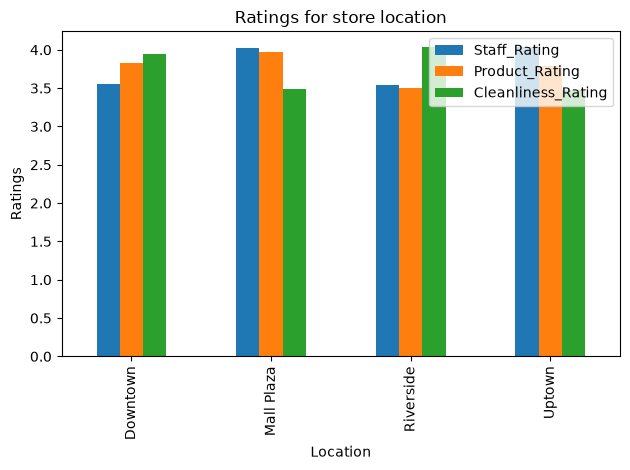

In [111]:
df.groupby('Store_Location')[['Staff_Rating','Product_Rating','Cleanliness_Rating']].mean().plot(kind='bar')
plt.xlabel("Location")
plt.ylabel("Ratings")
plt.title("Ratings for store location")
plt.tight_layout()
plt.show()

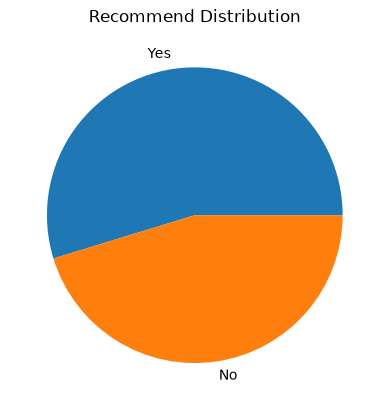

In [117]:
df['Recommend'].value_counts().plot(kind='pie')
plt.ylabel('')
plt.title('Recommend Distribution')
plt.show()

In [118]:
df.head(2)

,Survey_ID,Customer_ID,Store_Location,Visit_Date,Purchase_Amount,Wait_Time_Min,Staff_Rating,Product_Rating,Cleanliness_Rating,Recommend,Total_Rating,Month,Week,Staff_Rating_Category,Product_Rating_Category,Cleanliness_Rating_Category
0,SUR5117,CUST3117,Downtown,2024-02-16,391.88,23.9,3.0,4.0,2.0,No,3.00,2,Friday,Medium,High,Low
1,SUR5137,CUST3137,Uptown,2024-11-28,103.03,4.1,5.0,4.0,2.0,No,3.33,11,Thursday,High,High,Low


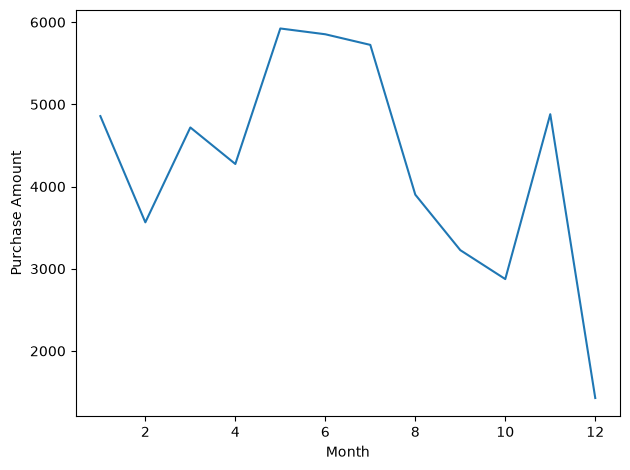

In [120]:
df.groupby('Month')['Purchase_Amount'].sum().plot(kind='line')
plt.xlabel("Month")
plt.ylabel("Purchase Amount")
plt.tight_layout()
plt.show()

# Seaborn

In [121]:
# Boxplot for Purchase_Amount by Store_Location

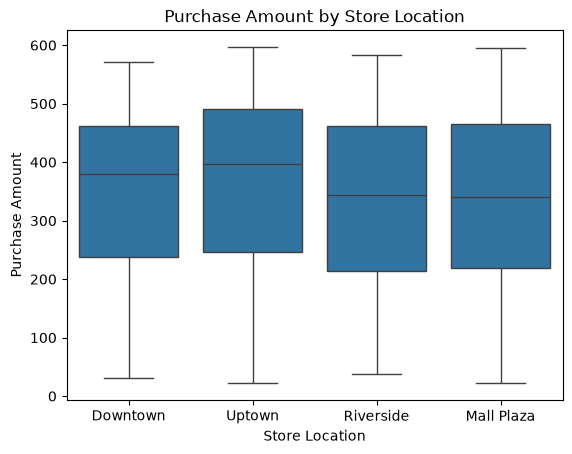

In [122]:
sns.boxplot(x='Store_Location',y='Purchase_Amount',data=df);
plt.xlabel("Store Location")
plt.ylabel("Purchase Amount")
plt.title("Purchase Amount by Store Location")
plt.show()

In [123]:
df.dtypes

Survey_ID                                 str
Customer_ID                               str
Store_Location                            str
Visit_Date                     datetime64[us]
Purchase_Amount                       float64
Wait_Time_Min                         float64
Staff_Rating                          float64
Product_Rating                        float64
Cleanliness_Rating                    float64
Recommend                                 str
Total_Rating                          float64
Month                                   int32
Week                                      str
Staff_Rating_Category                     str
Product_Rating_Category                   str
Cleanliness_Rating_Category               str
dtype: object

In [126]:
# Heatmap showing correlation between numeric variables.
num = ['Purchase_Amount','Wait_Time_Min','Staff_Rating','Product_Rating','Cleanliness_Rating','Total_Rating']

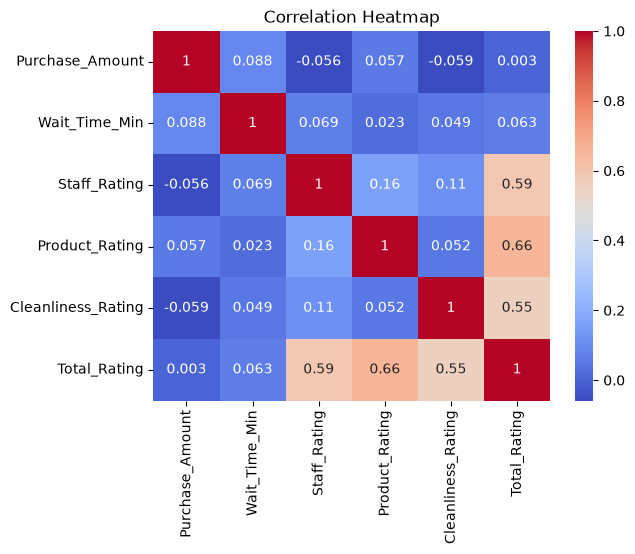

In [129]:
corr = df[num].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()